Veri setini yükleme

In [19]:
import pandas as pd

dosya_yolu = r"C:\Users\tuanasimsek\Desktop\VeriMadenciligiProjesi\data\birlesik_veri.csv"
df = pd.read_csv(dosya_yolu)

print("Veri boyutu (satır, sütun):", df.shape)
print("Sütunlar:", list(df.columns))

target = "vehicle_type"
if target not in df.columns:
    raise ValueError(f"Hedef sütun bulunamadı: {target}")

print("Hedef sütun:", target)
print("Sınıf sayısı:", df[target].nunique())
print("Sınıf dağılımı (adet):")
print(df[target].value_counts(dropna=False))


Veri boyutu (satır, sütun): (4599270, 9)
Sütunlar: ['hour', 'passenger_count', 'vehicle_type', 'route_code', 'stop_code', 'district', 'is_outlier', 'is_peak_hour', 'mean_passenger_by_route_hour']
Hedef sütun: vehicle_type
Sınıf sayısı: 3
Sınıf dağılımı (adet):
vehicle_type
2    1533090
1    1533090
3    1533090
Name: count, dtype: int64


Hedef Değişken Dağılım Analizi : 
- Hedef değişkenin sınıf bazlı adetleri hesaplanır
- Yüzdelik dağılımlar çıkarılır
- Bar grafiği ve pie grafiği ile görselleştirme yapılır

Bu analiz, veri setinin dengeli olup olmadığını göstermek amacıyla yapıldı.


Sınıf Dağılımı (Adet):
vehicle_type
1    1533090
2    1533090
3    1533090
Name: count, dtype: int64

Sınıf Dağılımı (Yüzde):
vehicle_type
1    33.33
2    33.33
3    33.33
Name: count, dtype: float64


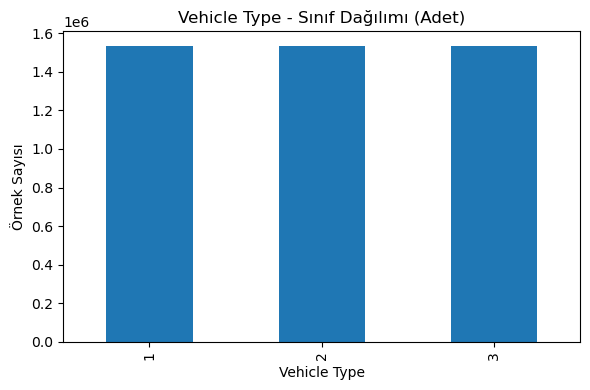

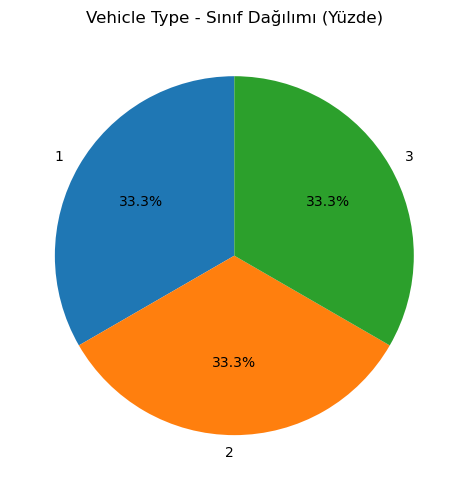

In [21]:
import matplotlib.pyplot as plt

# Sınıf dağılımı (adet)
sinif_adet = df[target].value_counts().sort_index()

# Yüzdelik dağılım
sinif_yuzde = (sinif_adet / sinif_adet.sum()) * 100

print("Sınıf Dağılımı (Adet):")
print(sinif_adet)

print("\nSınıf Dağılımı (Yüzde):")
print(sinif_yuzde.round(2))

# Bar grafiği
plt.figure(figsize=(6,4))
sinif_adet.plot(kind="bar")
plt.title("Vehicle Type - Sınıf Dağılımı (Adet)")
plt.xlabel("Vehicle Type")
plt.ylabel("Örnek Sayısı")
plt.tight_layout()
plt.show()

# Pie grafiği
plt.figure(figsize=(5,5))
plt.pie(
    sinif_yuzde,
    labels=sinif_yuzde.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Vehicle Type - Sınıf Dağılımı (Yüzde)")
plt.tight_layout()
plt.show()


Train / Validation / Test Ayrımı (Stratified)

- Veri seti %70 eğitim, %15 doğrulama, %15 test olacak şekilde ayrılmıştır
- Bölme işlemi sınıf dağılımı korunacak şekilde (stratified) yapılmıştır
- Her alt küme için sınıf dağılımları kontrol edilmiştir


In [23]:
from sklearn.model_selection import train_test_split

# Özellikler (X) ve hedef (y)
X = df.drop(columns=[target])
y = df[target]

# Önce train (%70) ve geçici (%30)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Geçici veriyi validation (%15) ve test (%15) olarak böl
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Veri boyutları:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Veri boyutları:
Train: (3219489, 8)
Validation: (689890, 8)
Test: (689891, 8)


Train / Validation / Test Veri Setlerinde Sınıf Dağılımı Analizi

Bu bölümde veri setinin train, validation ve test alt kümelerindeki sınıf dağılımları incelenmiştir.

- Her bir veri alt kümesi için sınıf başına örnek sayısı hesaplanmıştır.
- Aynı zamanda sınıfların veri seti içindeki yüzdesel dağılımları belirlenmiştir.
- Elde edilen sonuçlar tablo hâlinde birleştirilerek karşılaştırmalı olarak sunulmuştur.

Bu analiz sayesinde:
- Veri setindeki sınıf dengesizliği durumu açıkça görülmektedir.
- Train, validation ve test kümeleri arasında sınıf oranlarının
  tutarlı olup olmadığı kontrol edilmiştir.
- Model değerlendirmesinde neden Macro F1-score gibi metriklerin
  tercih edilmesi gerektiği gerekçelendirilmiştir.

Sınıf dağılımlarının dengesiz olması, yalnızca doğruluk (accuracy) metriğinin
yanıltıcı olabileceğini göstermektedir.

In [24]:
def sinif_dagilimi_ozet(y, ad):
    adet = y.value_counts().sort_index()
    yuzde = (adet / adet.sum()) * 100
    tablo = pd.DataFrame({
        f"{ad}_adet": adet,
        f"{ad}_yuzde": yuzde.round(2)
    })
    return tablo

dagilim_tablosu = (
    sinif_dagilimi_ozet(y_train, "train")
    .join(sinif_dagilimi_ozet(y_val, "val"))
    .join(sinif_dagilimi_ozet(y_test, "test"))
)

print("Train / Validation / Test sınıf dağılımları:")
display(dagilim_tablosu)


Train / Validation / Test sınıf dağılımları:


,train_adet,train_yuzde,val_adet,val_yuzde,test_adet,test_yuzde
vehicle_type,,,,,,
1,1073163,33.33,229964,33.33,229963,33.33
2,1073163,33.33,229963,33.33,229964,33.33
3,1073163,33.33,229963,33.33,229964,33.33


Özellik Setinin Tanımlanması ve Ön-İşleme 

- Tahmin edilecek hedef değişken: vehicle_type
- Modelde kullanılacak özellik sütunları belirlenir
- Olası bilgi sızıntısı (leakage) oluşturabilecek sütunlar, daha adil bir değerlendirme için çıkarılır
- Sayısal ve kategorik sütunlar ayrılır ve ön-işleme adımı hazırlanır


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Deney A: olası leakage sütunlarını çıkar
cikarilacak_kolonlar = ["route_code", "stop_code", "mean_passenger_by_route_hour"]

# Eğer sütun isimlerinden biri yoksa hata vermesin diye kontrol
cikarilacak_kolonlar = [c for c in cikarilacak_kolonlar if c in X_train.columns]

X_train_A = X_train.drop(columns=cikarilacak_kolonlar).copy()
X_val_A   = X_val.drop(columns=cikarilacak_kolonlar).copy()
X_test_A  = X_test.drop(columns=cikarilacak_kolonlar).copy()

print("Deney A - Kullanılan sütunlar:", list(X_train_A.columns))
print("Deney A - Sütun sayısı:", X_train_A.shape[1])

# Kategorik / sayısal sütunları ayır
kat_cols = X_train_A.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
say_cols = [c for c in X_train_A.columns if c not in kat_cols]

print("Sayısal sütunlar:", say_cols)
print("Kategorik sütunlar:", kat_cols)

# Preprocess: sayısala scaler, kategoriklere one-hot
preprocess_A = ColumnTransformer(
    transformers=[
        ("sayisal", Pipeline([("scaler", StandardScaler())]), say_cols),
        ("kategorik", Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))]), kat_cols),
    ],
    remainder="drop"
)


Deney A - Kullanılan sütunlar: ['hour', 'passenger_count', 'district', 'is_outlier', 'is_peak_hour']
Deney A - Sütun sayısı: 5
Sayısal sütunlar: ['hour', 'passenger_count', 'is_outlier', 'is_peak_hour']
Kategorik sütunlar: ['district']


XGBoost (Advanced Boosting) Modeli

- XGBoost sınıflandırıcı modeli kurulmuştur
- RandomizedSearchCV ile hiperparametre optimizasyonu yapılmıştır
- En iyi parametreler seçilerek test verisi üzerinde değerlendirme yapılmıştır


In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

print("Orijinal sınıflar:", label_encoder.classes_)
print("Encoded sınıflar:", set(y_train_enc))


Orijinal sınıflar: [1 2 3]
Encoded sınıflar: {0, 1, 2}


XGBoost Modeli ve Hiperparametre Optimizasyonu

Bu bölümde, çok sınıflı sınıflandırma problemi için
XGBoost (Extreme Gradient Boosting) algoritması kullanılarak bir model kurulmuştur.

- Model, Pipeline yapısı içerisinde tanımlanarak veri ön işleme adımı ile XGBoost sınıflandırıcısı birleştirilmiştir.
- Hedef değişken üç sınıftan oluştuğu için (num_class = 3), model çok sınıflı sınıflandırma problemi olarak ele alınmıştır.
- Model performansının sınıf dengesizliğinden etkilenmemesi amacıyla değerlendirme metriği olarak Macro F1-score seçilmiştir.

Hiperparametre Optimizasyonu
- XGBoost modelinin performansını artırmak amacıyla RandomizedSearchCV kullanılarak hiperparametre optimizasyonu yapılmıştır.
- Çapraz doğrulama yöntemi olarak, sınıf oranlarını koruyan StratifiedKFold tercih edilmiştir.

Model Seçimi
- En iyi hiperparametre kombinasyonu, çapraz doğrulama sürecinde elde edilen F1-macro skoruna göre belirlenmiştir.
- Optimizasyon sonucunda elde edilen en iyi model,test veri seti üzerinde nihai değerlendirme için saklanmıştır.

Bu yaklaşım sayesinde modelin,tüm sınıflar üzerindeki performansı dengeli şekilde ölçülmüş ve genelleme kabiliyeti artırılmıştır.


In [29]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess_A),
    ("model", xgb_model)
])

param_dist = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_xgb.fit(X_train_A, y_train_enc)

print("En iyi parametreler:")
print(search_xgb.best_params_)

print("En iyi CV skoru (F1-macro):")
print(search_xgb.best_score_)

best_xgb = search_xgb.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
En iyi parametreler:
{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
En iyi CV skoru (F1-macro):
0.7492807458697789


XGBoost Test Performansının Değerlendirilmesi

Bu bölümde, hiperparametre optimizasyonu sonucunda elde edilen en iyi XGBoost modeli test veri seti üzerinde değerlendirilmiştir.

- Modelin test verisi üzerindeki tahminleri (xgb_test_pred) elde edilmiştir.
- Performans değerlendirmesinde yalnızca tek bir metrik yerine, çoklu ve dengeli metrikler kullanılmıştır.

Kullanılan Performans Metrikleri
- Accuracy: Modelin genel doğru sınıflandırma oranını gösterir.
- Balanced Accuracy: Sınıf dengesizliğini dikkate alarak, her sınıf için doğruluk değerlerinin ortalamasını hesaplar.
- Precision (Macro): Tüm sınıflar için kesinlik değerlerinin ortalamasını verir.
- Recall (Macro): Modelin her sınıfı ne kadar iyi yakalayabildiğini ölçer.
- F1-score (Macro): Precision ve Recall değerlerinin dengeli ortalamasıdır ve sınıf dengesizliği bulunan problemlerde tercih edilir.

Sınıf Bazlı Analiz
- classification_report kullanılarak Deniz, Kara ve Raylı sınıfları için ayrı ayrı precision, recall ve F1-score değerleri hesaplanmıştır.
- confusion_matrix ile modelin hangi sınıfları birbiriyle karıştırdığı görsel olarak analiz edilebilir hâle getirilmiştir.

Bu değerlendirme sayesinde, XGBoost modelinin hem genel performansı hem de sınıf bazlı başarımı ayrıntılı biçimde analiz edilmiştir.

In [30]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Test tahminleri
xgb_test_pred = best_xgb.predict(X_test_A)

# Metrikler
acc = accuracy_score(y_test_enc, xgb_test_pred)
bacc = balanced_accuracy_score(y_test_enc, xgb_test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test_enc, xgb_test_pred, average="macro"
)

print("XGBoost Test Sonuçları")
print("Accuracy:", acc)
print("Balanced Accuracy:", bacc)
print("Precision (macro):", prec)
print("Recall (macro):", rec)
print("F1-score (macro):", f1)

print("\nSınıf Bazlı Rapor:")
print(
    classification_report(
        y_test_enc,
        xgb_test_pred,
        target_names=label_encoder.classes_.astype(str)
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_enc, xgb_test_pred))


XGBoost Test Sonuçları
Accuracy: 0.7544916515797423
Balanced Accuracy: 0.7544918759851532
Precision (macro): 0.7543077078789989
Recall (macro): 0.7544918759851532
F1-score (macro): 0.7496033786850248

Sınıf Bazlı Rapor:
              precision    recall  f1-score   support

           1       0.76      0.91      0.83    229963
           2       0.76      0.61      0.68    229964
           3       0.74      0.74      0.74    229964

    accuracy                           0.75    689891
   macro avg       0.75      0.75      0.75    689891
weighted avg       0.75      0.75      0.75    689891

Confusion Matrix:
[[209107  14594   6262]
 [ 36862 140764  52338]
 [ 28964  30354 170646]]


XGBoost ROC Eğrileri (One-vs-Rest)

- Çok sınıflı sınıflandırma problemi için One-vs-Rest yaklaşımı kullanılmıştır
- Her sınıf için ROC eğrisi ve AUC değeri hesaplanmıştır


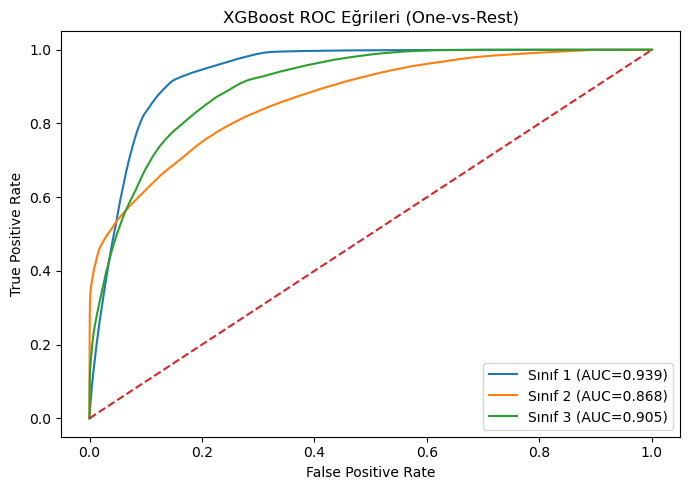

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Olasılık tahminleri
xgb_test_proba = best_xgb.predict_proba(X_test_A)

# Binarize true labels
classes = np.unique(y_test_enc)
y_test_bin = label_binarize(y_test_enc, classes=classes)

plt.figure(figsize=(7,5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], xgb_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Sınıf {label_encoder.classes_[cls]} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Eğrileri (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()


PyTorch MLP (Fully Connected Neural Network)

- Aynı özellik seti (Deney A) kullanılarak PyTorch tabanlı bir MLP modeli kurulmuştur
- Model epoch bazlı olarak eğitilmiş ve doğrulama verisi ile izlenmiştir


In [34]:
import torch
from torch.utils.data import Dataset, DataLoader

# Preprocess ile sayısal hale getir
X_train_pt = preprocess_A.fit_transform(X_train_A)
X_val_pt   = preprocess_A.transform(X_val_A)
X_test_pt  = preprocess_A.transform(X_test_A)

# Sparse gelirse dense'e çevir
if hasattr(X_train_pt, "toarray"):
    X_train_pt = X_train_pt.toarray()
    X_val_pt   = X_val_pt.toarray()
    X_test_pt  = X_test_pt.toarray()

# Tensor'a çevir
X_train_pt = torch.tensor(X_train_pt, dtype=torch.float32)
X_val_pt   = torch.tensor(X_val_pt, dtype=torch.float32)
X_test_pt  = torch.tensor(X_test_pt, dtype=torch.float32)

y_train_pt = torch.tensor(y_train_enc, dtype=torch.long)
y_val_pt   = torch.tensor(y_val_enc, dtype=torch.long)
y_test_pt  = torch.tensor(y_test_enc, dtype=torch.long)

print("Giriş boyutu:", X_train_pt.shape[1])


Giriş boyutu: 44


In [35]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    TabularDataset(X_train_pt, y_train_pt),
    batch_size=1024,
    shuffle=True
)

val_loader = DataLoader(
    TabularDataset(X_val_pt, y_val_pt),
    batch_size=2048,
    shuffle=False
)

test_loader = DataLoader(
    TabularDataset(X_test_pt, y_test_pt),
    batch_size=2048,
    shuffle=False
)


PyTorch Çok Katmanlı Algılayıcı (MLP) Modelinin Tanımlanması

Bu bölümde, çok sınıflı sınıflandırma problemi için PyTorch tabanlı bir Çok Katmanlı Algılayıcı (MLP) mimarisi tanımlanmıştır.

Model Mimarisi
Oluşturulan MLP modeli aşağıdaki bileşenlerden oluşmaktadır:

- Giriş Katmanı: Girdi boyutu, eğitim verisindeki özellik sayısına (input_dim) göre dinamik olarak belirlenmiştir.

- Gizli Katmanlar: 
  - 1. gizli katman: 256 nöron  
  - 2. gizli katman: 128 nöron  

- Batch Normalization: Her gizli katmandan sonra kullanılarak, eğitimin daha kararlı ve hızlı ilerlemesi sağlanmıştır.

- ReLU Aktivasyon Fonksiyonu: Doğrusal olmayan ilişkilerin öğrenilmesi için tercih edilmiştir.

- Dropout (0.3): Aşırı öğrenmeyi (overfitting) azaltmak amacıyla uygulanmıştır.

- Çıkış Katmanı: Nöron sayısı, hedef sınıf sayısına (num_classes) eşittir ve çok sınıflı sınıflandırmaya uygundur.

Donanım Kullanımı
- Model, kullanılabilir olması durumunda GPU (CUDA) üzerinde,aksi hâlde CPU üzerinde çalışacak şekilde yapılandırılmıştır.

Bu yapı, derinliği sınırlı ancak genelleme yeteneği yüksek,çok sınıflı problemler için uygun bir MLP mimarisi sunmaktadır.

In [36]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP(
    input_dim=X_train_pt.shape[1],
    num_classes=len(label_encoder.classes_)
).to(device)

print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=44, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)


PyTorch MLP Modeli – Eğitim ve Doğrulama Süreci

Bu bölümde PyTorch kullanılarak oluşturulan MLP modelinin
eğitim ve doğrulama süreci gerçekleştirilmiştir.

- Kayıp fonksiyonu olarak CrossEntropyLoss kullanılmıştır.
- Optimizasyon işlemi Adam optimizer ile yapılmıştır.
- Model, belirlenen epoch sayısı boyunca eğitim verisi üzerinde öğrenmiştir.
- Her epoch sonunda:
  - Eğitim kaybı (Train Loss) ve doğruluğu (Train Accuracy)
  - Doğrulama kaybı (Validation Loss), doğruluğu (Validation Accuracy)
  - Macro F1-score değeri hesaplanmıştır.
- model.train() ve model.eval() kullanılarak eğitim ve doğrulama modları ayrılmıştır.

Bu yapı sayesinde modelin aşırı öğrenme (overfitting) durumu izlenmiş ve
genelleme başarısı değerlendirilmiştir.

In [37]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

# Loss ve optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    # ======================
    # TRAIN
    # ======================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ======================
    # VALIDATION
    # ======================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(y_batch.cpu().numpy())

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_val_labels, all_val_preds, average="macro")

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )


Epoch [1/10] | Train Loss: 0.5709 | Train Acc: 0.7465 | Val Loss: 0.5585 | Val Acc: 0.7514 | Val F1: 0.7463
Epoch [2/10] | Train Loss: 0.5622 | Train Acc: 0.7499 | Val Loss: 0.5567 | Val Acc: 0.7522 | Val F1: 0.7466
Epoch [3/10] | Train Loss: 0.5606 | Train Acc: 0.7502 | Val Loss: 0.5555 | Val Acc: 0.7527 | Val F1: 0.7477
Epoch [4/10] | Train Loss: 0.5595 | Train Acc: 0.7505 | Val Loss: 0.5548 | Val Acc: 0.7524 | Val F1: 0.7475
Epoch [5/10] | Train Loss: 0.5589 | Train Acc: 0.7507 | Val Loss: 0.5551 | Val Acc: 0.7528 | Val F1: 0.7476
Epoch [6/10] | Train Loss: 0.5582 | Train Acc: 0.7511 | Val Loss: 0.5541 | Val Acc: 0.7529 | Val F1: 0.7476
Epoch [7/10] | Train Loss: 0.5577 | Train Acc: 0.7511 | Val Loss: 0.5536 | Val Acc: 0.7529 | Val F1: 0.7474
Epoch [8/10] | Train Loss: 0.5574 | Train Acc: 0.7514 | Val Loss: 0.5540 | Val Acc: 0.7536 | Val F1: 0.7477
Epoch [9/10] | Train Loss: 0.5570 | Train Acc: 0.7514 | Val Loss: 0.5530 | Val Acc: 0.7531 | Val F1: 0.7479
Epoch [10/10] | Train Loss: 

In [43]:
model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(y_batch.cpu().numpy())

# NumPy array olarak al
y_test_pred = all_test_preds
y_test_true = all_test_labels


Model Performanslarının Karşılaştırmalı Değerlendirilmesi (XGBoost & PyTorch MLP)

Bu bölümde, eğitilmiş XGBoost ve PyTorch MLP (Fully Connected Neural Network) modellerinin test verisi üzerindeki performansları karşılaştırmalı olarak değerlendirilmiştir.

Değerlendirme sürecinde, Accuracy, Macro F1-score, sınıf bazlı precision–recall–F1 değerleri ve confusion matrix metrikleri kullanılmıştır.

Sınıf isimleri Deniz, Kara ve Raylı olacak şekilde tanımlanarak, model çıktılarının raporlanması daha yorumlanabilir hâle getirilmiştir.

Ortak bir evaluate_model fonksiyonu tanımlanarak, farklı modellerin aynı metrikler ve aynı test verisi üzerinden değerlendirilmesi sağlanmıştır.

Bu yapı sayesinde, modeller arası performans farkları adil ve tutarlı bir biçimde analiz edilebilmiştir.

Elde edilen sonuçlar hem konsol çıktısı olarak hem de pandas DataFrame formatında sunularak raporlamaya uygun hâle getirilmiştir.

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd

target_names = ["Deniz", "Kara", "Rayli"]

def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    # DataFrame olarak da görmek istersen:
    rep = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(rep).T

# 1) XGBoost (sende genelde xgb_test_pred vardı)
df_xgb = evaluate_model("XGBoost", y_test_enc, xgb_test_pred)

# 2) PyTorch MLP (sende y_test_pred veya mlp_test_pred olabilir)
df_mlp = evaluate_model("PyTorch MLP", y_test_enc, y_test_pred)

display(df_xgb)
display(df_mlp)


===== XGBoost =====
Accuracy: 0.7544916515797423
Macro F1: 0.7496033786850248

Classification Report:
              precision    recall  f1-score   support

       Deniz       0.76      0.91      0.83    229963
        Kara       0.76      0.61      0.68    229964
       Rayli       0.74      0.74      0.74    229964

    accuracy                           0.75    689891
   macro avg       0.75      0.75      0.75    689891
weighted avg       0.75      0.75      0.75    689891

Confusion Matrix:
[[209107  14594   6262]
 [ 36862 140764  52338]
 [ 28964  30354 170646]]

===== PyTorch MLP =====
Accuracy: 0.7531827491589251
Macro F1: 0.7482159729167329

Classification Report:
              precision    recall  f1-score   support

       Deniz       0.76      0.91      0.83    229963
        Kara       0.75      0.61      0.67    229964
       Rayli       0.75      0.74      0.74    229964

    accuracy                           0.75    689891
   macro avg       0.75      0.75      0.75   

,precision,recall,f1-score,support
Deniz,0.760574,0.909307,0.828317,229963.000000
Kara,0.757969,0.612113,0.677277,229964.000000
Rayli,0.744379,0.742055,0.743216,229964.000000
accuracy,0.754492,0.754492,0.754492,0.754492
macro avg,0.754308,0.754492,0.749603,689891.000000
weighted avg,0.754308,0.754492,0.749603,689891.000000


,precision,recall,f1-score,support
Deniz,0.759041,0.909820,0.827619,229963.000000
Kara,0.753995,0.610556,0.674737,229964.000000
Rayli,0.745438,0.739172,0.742292,229964.000000
accuracy,0.753183,0.753183,0.753183,0.753183
macro avg,0.752825,0.753183,0.748216,689891.000000
weighted avg,0.752825,0.753183,0.748216,689891.000000


PyTorch MLP (Fully Connected Neural Network) – Test ve Performans Değerlendirmesi

Bu bölümde, PyTorch kullanılarak eğitilen MLP (Fully Connected Neural Network) modelinin test verisi üzerindeki performansı değerlendirilmiştir.

Model, model.eval() ve torch.no_grad() kullanılarak eğitim dışı (inference) modunda çalıştırılmıştır.

Test verisi, DataLoader aracılığıyla batch bazlı olarak modele verilmiş ve her batch için tahmin edilen sınıflar elde edilmiştir.

Model çıktıları üzerinde argmax işlemi uygulanarak nihai sınıf tahminleri üretilmiştir.

Gerçek etiketler ve model tahminleri biriktirilerek test kümesi için:

Accuracy ,Sınıf bazlı precision, recall ve F1-score ,Confusion Matrix ,metrikleri hesaplanmıştır.

Sınıf isimleri, Deniz – Kara – Raylı olacak şekilde etiketlenmiş ve sonuçlar sınıf bazlı olarak raporlanmıştır.

Bu değerlendirme, PyTorch MLP modelinin çok sınıflı sınıflandırma problemi üzerindeki başarısını ayrıntılı biçimde analiz etmek amacıyla gerçekleştirilmiştir.


In [51]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(y_batch.cpu().numpy())

print("PyTorch MLP Test Sonuçları")
print("Accuracy:", accuracy_score(all_test_labels, all_test_preds))
print("\nSınıf Bazlı Rapor:")
print(
    classification_report(
        all_test_labels,
        all_test_preds,
        target_names=label_encoder.classes_.astype(str)
    )
)

print("Confusion Matrix:")
print(confusion_matrix(all_test_labels, all_test_preds))


PyTorch MLP Test Sonuçları
Accuracy: 0.7531827491589251

Sınıf Bazlı Rapor:
              precision    recall  f1-score   support

           1       0.76      0.91      0.83    229963
           2       0.75      0.61      0.67    229964
           3       0.75      0.74      0.74    229964

    accuracy                           0.75    689891
   macro avg       0.75      0.75      0.75    689891
weighted avg       0.75      0.75      0.75    689891

Confusion Matrix:
[[209225  15115   5623]
 [ 37133 140406  52425]
 [ 29286  30695 169983]]
